In [1]:
import pandas as pd
import numpy as np
from os import getcwd, listdir, path
import matplotlib.pyplot as plt
import sys
import ast
from glob import glob

import fitness.data_generating_process as dgp
import fitness.soga_fitness_SCM as soga_fitness_SCM
import fitness.interventions as interventions

In [2]:
# Read all pareto_fitness.txt files under results/causal_skills_tests and build aggregated stats
program = 'chain'
ex_name = program
base_dir = path.join('..', 'results', ex_name)
pattern = path.join(base_dir, '**', 'stats.tsv')

# Read ONLY the column best_fitness from all stats.tsv files, change the value tensor(-1000000.) to -1000000.0, and FOR EACH ROW compute mean, std, median and interquartile ranges (25, 75)
# and save the results in a new dataframe with columns: mean, std, median, q25, q75.Do not consider interventions.

files = glob(pattern, recursive=True)
dfs = []
for file in files:
    df = pd.read_csv(file, sep='\t')
    df['best_fitness'] = df['best_fitness'].replace('tensor(-1000000.)', -1000000.0).astype(float)
    dfs.append(df[['best_fitness']])

# for each row, compute mean, std, median, q25 and q75
results = []
for i in range(len(dfs[0])):
    values = [df['best_fitness'].iloc[i] for df in dfs]
    mean = np.mean(values)
    std = np.std(values)
    median = np.median(values)
    q25 = np.percentile(values, 25)
    q75 = np.percentile(values, 75)
    results.append({'mean': mean, 'std': std, 'median': median, 'q25': q25, 'q75': q75})

results_df = pd.DataFrame(results)
print(results_df)


            mean        std      median         q25         q75
0    -201.838933  72.405206 -187.502795 -260.154777 -139.734474
1    -152.374865  44.139123 -135.177485 -145.938779 -130.851757
2    -134.628289  35.155114 -126.283423 -139.329181 -122.392413
3    -122.747111  17.994203 -123.850105 -130.466419 -118.341310
4    -118.541404  16.244468 -119.429686 -123.349973 -114.641365
...          ...        ...         ...         ...         ...
1496  -71.699202  10.015842  -74.095544  -76.822069  -61.952528
1497  -71.699202  10.015842  -74.095544  -76.822069  -61.952528
1498  -71.699202  10.015842  -74.095544  -76.822069  -61.952528
1499  -71.699202  10.015842  -74.095544  -76.822069  -61.952528
1500  -71.699202  10.015842  -74.095544  -76.822069  -61.952528

[1501 rows x 5 columns]


In [3]:
vars, scm = dgp.get_vars(program)
real_program = dgp.get_real_program(program)
baseline_program = dgp.get_baseline_program(program)
#real_dataset = dgp.generate_interventional_dataset(scm, vars, 1000)

real_dataset_file = f'fitness/datasets/{program}.csv'
real_dataset = np.loadtxt(real_dataset_file, delimiter=',')

likelihood = soga_fitness_SCM.compute_likelihood(real_program, vars, real_dataset)
likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program, vars, real_dataset)

likelihood_intervened = 0
likelihood_base_intervened = 0
print(f'Likelihood of real program: {likelihood}')
print(f'\nLikelihood of baseline program: {likelihood_base}')
interventions_list = dgp.get_intervention_list(program)
for var, value in interventions_list:
    dataset_file = f'fitness/datasets/{program}_intervention_{var}_{value}.csv'
    data_intervened = np.loadtxt(dataset_file, delimiter=',')
    program_intervened = interventions.apply_intervention_to_program(real_program, var, value)
    baseline_program_intervened = interventions.apply_intervention_to_program(baseline_program, var, value)
    interventional_likelihood = soga_fitness_SCM.compute_likelihood(program_intervened, vars, data_intervened)
    interventional_likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program_intervened, vars, data_intervened)
    likelihood_intervened += interventional_likelihood
    likelihood_base_intervened += interventional_likelihood_base


likelihood = likelihood + likelihood_intervened
likelihood_base = likelihood_base + likelihood_base_intervened
print(f'Total likelihood of real program: {likelihood}')
print(f'Total likelihood of baseline program: {likelihood_base}')


Likelihood of real program: -7.429976348251426

Likelihood of baseline program: -9.562688828918981
Total likelihood of real program: -56.530800558962014
Total likelihood of baseline program: -119.09960404177751


In [4]:
# between all the files, find the one with best likelihood and print the corresponding program
best_likelihood = -np.inf
best_program = None
for file in files:
    df = pd.read_csv(file, sep='\t')
    df['best_fitness'] = df['best_fitness'].replace('tensor(-1000000.)', -1000000.0).astype(float)
    max_likelihood = df['best_fitness'].max()
    if max_likelihood > best_likelihood:
        best_likelihood = max_likelihood
        best_program = file 
print(f'Best likelihood: {best_likelihood}')
#print(f'Best program file: {best_program}')

#in the folder where the best stats.tsv file is, print the content of the best.txt file
best_program_file = best_program.replace('stats.tsv', 'best.txt')
with open(best_program_file, 'r') as f:
    best_program_content = f.read()
print(f'Best program content:\n{best_program_content}')

Best likelihood: -57.66383769656945
Best program content:
Generation:
1500

Phenotype:
1
V1 = gm([5.2e0, +9.9e0, 2.0e0]);
V2 = +V1;
V2 = V2 + uniform([-2.0e0, 4.0e0], 2);
V3 = -V2 * -V2;
V3 = V3 + gm([7.4e1, +0.4e0, 1.0e1]);

Pre-processed Program
:F = gm([1.000000], [9.9], [2]);T = F;T = T + uniform([-2.000000, 2.000000], 2);TEMP0 = T * T;P = TEMP0;P = P + gm([1.000000], [0.4], [10]);Genotype:
[404, 234, 102, 98, 37, 398, 33, 5, 352, 264, 469, 104, 29, 299, 228, 150, 492, 170, 202, 151, 178, 310, 468, 438, 401, 45, 324, 360, 137, 102, 70, 88, 388, 134, 500, 104, 100, 496, 263, 48, 418, 411, 87, 42, 307, 121, 234, 420, 420, 350, 347, 64, 441, 401, 132, 200, 4, 160, 190, 1, 90, 309, 34, 296, 113, 74, 14, 208, 240, 41, 0, 157, 140, 333, 6, 133, 88, 90, 378, 439, 128, 489, 68, 306, 63, 448, 19, 469, 177, 95, 479, 197, 127, 392, 282, 345, 338, 224, 319, 191, 370, 410, 209, 64, 287, 336, 75, 175, 193, 132, 176, 423, 63, 468, 252, 319, 250, 68, 465, 468, 196, 47, 185, 143, 289, 176, 165, 135

In [5]:
# Read all pareto_fitness.txt files under results/causal_skills_tests and build aggregated stats
ex_name_independent = ex_name + '_independent'
base_dir_independent = path.join('..', 'results', ex_name_independent)
pattern_independent = path.join(base_dir_independent, '**', 'stats.tsv')

# Read ONLY the column best_fitness from all stats.tsv files, change the value tensor(-1000000.) to -1000000.0, and FOR EACH ROW compute mean, std, median and interquartile ranges (25, 75)
# and save the results in a new dataframe with columns: mean, std, median, q25, q75.Do not consider interventions.

files_independent = glob(pattern_independent, recursive=True)
dfs = []
for file in files_independent:
    df = pd.read_csv(file, sep='\t')
    df['best_fitness'] = df['best_fitness'].replace('tensor(-1000000.)', -1000000.0).astype(float)
    dfs.append(df[['best_fitness']])

# for each row, compute mean, std, median, q25 and q75
results = []
for i in range(len(dfs[0])):
    values = [df['best_fitness'].iloc[i] for df in dfs]
    mean = np.mean(values)
    std = np.std(values)
    median = np.median(values)
    q25 = np.percentile(values, 25)
    q75 = np.percentile(values, 75)
    results.append({'mean': mean, 'std': std, 'median': median, 'q25': q25, 'q75': q75})

results_df_independent = pd.DataFrame(results)
print(results_df_independent)


            mean        std      median         q25         q75
0    -122.866938  11.894946 -123.651968 -131.093046 -117.454315
1    -117.154487   8.703563 -118.316496 -122.266214 -115.269693
2    -112.927727   6.370058 -114.537988 -116.309966 -110.229627
3    -109.892752   7.768308 -110.997990 -115.471636 -105.480370
4    -107.552528   6.405360 -108.057488 -113.158161 -104.821027
...          ...        ...         ...         ...         ...
1496  -87.724586   0.882044  -87.486004  -88.057882  -87.243989
1497  -87.724586   0.882044  -87.486004  -88.057882  -87.243989
1498  -87.724586   0.882044  -87.486004  -88.057882  -87.243989
1499  -87.724586   0.882044  -87.486004  -88.057882  -87.243989
1500  -87.724586   0.882044  -87.486004  -88.057882  -87.243989

[1501 rows x 5 columns]


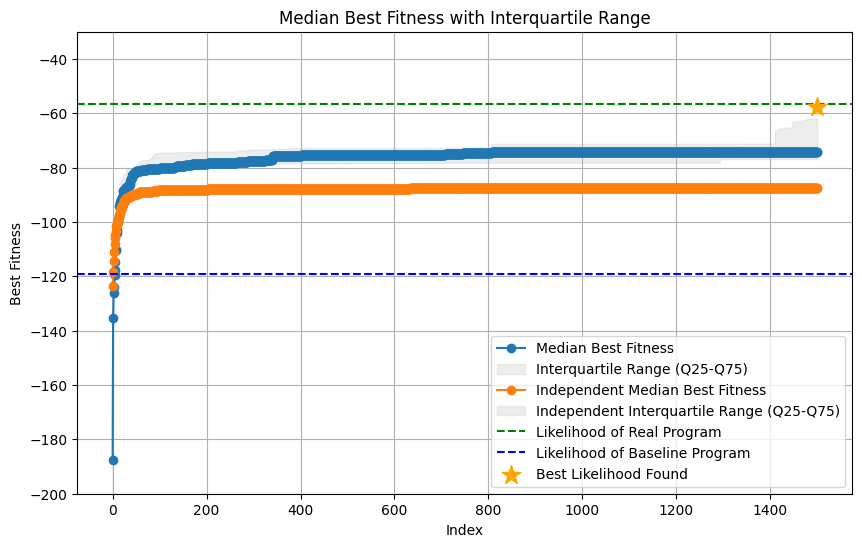

In [6]:
# Plot results_df median with shaded interquartile range
plt.figure(figsize=(10, 6))
plt.plot(results_df.index, results_df['median'], 'o-', label='Median Best Fitness')
plt.fill_between(
    results_df.index,
    results_df['q25'],
    results_df['q75'],
    color='lightgray',
    alpha=0.4,
    label='Interquartile Range (Q25-Q75)'
)

plt.plot(results_df_independent.index, results_df_independent['median'], 'o-', label='Independent Median Best Fitness')
plt.fill_between(
    results_df_independent.index,
    results_df_independent['q25'],
    results_df_independent['q75'],
    color='lightgray',
    alpha=0.4,
    label='Independent Interquartile Range (Q25-Q75)'
)


plt.title('Median Best Fitness with Interquartile Range')
plt.xlabel('Index')
plt.ylabel('Best Fitness')
plt.ylim(-200, -30)

# Add a horizontal line for the likelihood of the real program and the baseline program
plt.axhline(y=likelihood, color='g', linestyle='--', label='Likelihood of Real Program')
plt.axhline(y=likelihood_base, color='b', linestyle='--', label='Likelihood of Baseline Program')

# Add a point for the best likelihood found in the files with the shape of a star and color orange
plt.scatter(len(results_df)-1, best_likelihood, color='orange', label='Best Likelihood Found', zorder=5, marker='*', s=200)

plt.legend()

plt.grid()
plt.show()

In [7]:
# create a file in the folder ../results/files with 6 columns: median (results_df['median']), q25 (results_df['q25']), q75 (results_df['q75']), median_independent (results_df_independent['median']), q25_independent (results_df_independent['q25']), q75_independent (results_df_independent['q75'])
# the numbers must be saved with 3 decimal places
output_file = path.join('..', 'results', 'files', ex_name + '_fitness_stats.tsv')
results_df_output = pd.DataFrame({
    'median': results_df['median'],
    'q25': results_df['q25'],
    'q75': results_df['q75'],
    'median_independent': results_df_independent['median'],
    'q25_independent': results_df_independent['q25'],
    'q75_independent': results_df_independent['q75']
})
results_df_output = results_df_output.round(3)
results_df_output.to_csv(output_file, sep='\t', index=False)

In [8]:
no_int_ex_name = ex_name + '_no_interventions'

# Read all best.txt files under results/chain_no_interventions and compute the likelihood of the program in each best.txt file (it's between "Pre-processed Program \n :" and "Tree:")
pattern_no_int = path.join('..', 'results', no_int_ex_name, '**', 'best.txt')
files_no_int = glob(pattern_no_int, recursive=True)
likelihoods_no_int = []
likelihoods_no_int_no_interventions = []
for file in files_no_int:
    with open(file, 'r') as f:
        content = f.read()
    program_start = content.find('Pre-processed Program') + len('Pre-processed Program')
    program_end = content.find('Genotype:')
    program_str = content[program_start:program_end].strip()
    #remove the : at the beginning
    program_str = program_str.lstrip(':')
    #print(f'Program string:\n{program_str}')
    #program_ast = ast.literal_eval(program_str)
    likelihood_no_int_no_interventions = soga_fitness_SCM.compute_likelihood(program_str, vars, real_dataset)
    #print(f'Likelihood of program found without interventions: {likelihood_no_int}')
    interventions_list = dgp.get_intervention_list(program)
    likelihood_no_int = 0
    for var, value in interventions_list:
        dataset_file = f'fitness/datasets/{program}_intervention_{var}_{value}.csv'
        data_intervened = np.loadtxt(dataset_file, delimiter=',')
        program_intervened = interventions.apply_intervention_to_program(program_str, var, value)
        #print(f'Program intervened:\n{program_intervened}')
        try:
            interventional_likelihood = soga_fitness_SCM.compute_likelihood(program_intervened, vars, data_intervened)
        except Exception as e:
            print(f'Error computing likelihood for intervention {var}={value}: {e}')
            interventional_likelihood = -1000000.0
        #print(f'Interventional likelihood for intervention {var}={value}: {interventional_likelihood}')
        likelihood_no_int += interventional_likelihood

    likelihoods_no_int.append(likelihood_no_int)
    likelihoods_no_int_no_interventions.append(likelihood_no_int_no_interventions)

likelihoods_no_int = [x + y for x, y in zip(likelihoods_no_int, likelihoods_no_int_no_interventions)]
print(f'Likelihoods of programs found without interventions: {likelihoods_no_int_no_interventions}')
print(f'Likelihoods of programs found interventions: {likelihoods_no_int}')

Likelihoods of programs found without interventions: [tensor(-8.3925), tensor(-7.6889), tensor(-8.1956), tensor(-7.5197), tensor(-8.3443), tensor(-7.4147), tensor(-7.6154), tensor(-7.5082), tensor(-7.6195), tensor(-7.5080)]
Likelihoods of programs found interventions: [tensor(-87.3466), tensor(-396.3175), tensor(-89.1498), tensor(-58.1623), tensor(-198.7877), tensor(-57.0098), tensor(-3000073.4992), tensor(-101.3801), tensor(-330.7047), tensor(-57.7314)]


In [9]:
# between all the files, find the one with best likelihood and print the corresponding program
base_dir_no_interventions = path.join('..', 'results', no_int_ex_name)
pattern_no_interventions = path.join(base_dir_no_interventions, '**', 'stats.tsv')

# Read ONLY the column best_fitness from all stats.tsv files, change the value tensor(-1000000.) to -1000000.0, and FOR EACH ROW compute mean, std, median and interquartile ranges (25, 75)
# and save the results in a new dataframe with columns: mean, std, median, q25, q75.Do not consider interventions.

files_no_interventions = glob(pattern_no_interventions, recursive=True)
dfs_no_int = []
for file in files_no_interventions:
    df_no_int = pd.read_csv(file, sep='\t')
    df_no_int['best_fitness'] = df_no_int['best_fitness'].replace('tensor(-1000000.)', -1000000.0).astype(float)
    dfs_no_int.append(df_no_int[['best_fitness']])

# for each row, compute mean, std, median, q25 and q75
results_no_int = []
for i in range(len(dfs_no_int[0])):
    values = [df_no_int['best_fitness'].iloc[i] for df_no_int in dfs_no_int]
    mean = np.mean(values)
    std = np.std(values)
    median = np.median(values)
    q25 = np.percentile(values, 25)
    q75 = np.percentile(values, 75)
    results_no_int.append({'mean': mean, 'std': std, 'median': median, 'q25': q25, 'q75': q75})

results_df_no_interventions = pd.DataFrame(results_no_int)
print(results_df_no_interventions)


best_likelihood_no_interventions= -np.inf
best_program_no_interventions = None
for file in files_no_interventions:
    df_no_int = pd.read_csv(file, sep='\t')
    df_no_int['best_fitness'] = df_no_int['best_fitness'].replace('tensor(-1000000.)', -1000000.0).astype(float)
    max_likelihood_no_interventions = df_no_int['best_fitness'].max()
    if max_likelihood_no_interventions > best_likelihood_no_interventions:
        best_likelihood_no_interventions = max_likelihood_no_interventions
        best_program_no_interventions = file 
print(f'Best likelihood: {best_likelihood_no_interventions}')
#print(f'Best program file: {best_program_no_interventions}')

#in the folder where the best stats.tsv file is, print the content of the best.txt file
best_program_file = best_program_no_interventions.replace('stats.tsv', 'best.txt')
with open(best_program_file, 'r') as f:
    best_program_content = f.read()
print(f'Best program content:\n{best_program_content}')

           mean       std     median        q25        q75
0    -17.344089  4.036925 -15.657521 -18.977632 -14.517049
1    -14.854990  1.642433 -14.379000 -15.491405 -13.928547
2    -14.164888  1.516470 -14.042677 -14.470542 -13.234631
3    -13.265996  0.818956 -13.309406 -13.709104 -12.522754
4    -12.799238  0.915024 -12.956156 -13.352960 -11.973233
...         ...       ...        ...        ...        ...
1496  -7.776095  0.354584  -7.619185  -8.064970  -7.513165
1497  -7.775249  0.353607  -7.619185  -8.058629  -7.513165
1498  -7.775249  0.353607  -7.619185  -8.058629  -7.513165
1499  -7.775249  0.353607  -7.619185  -8.058629  -7.513165
1500  -7.775249  0.353607  -7.619185  -8.058629  -7.513165

[1501 rows x 5 columns]
Best likelihood: -7.406059149743461
Best program content:
Generation:
1500

Phenotype:
1
V1 = gm([2.6e1, +9.9e0, 2.0e0]);
V2 = +V1;
V2 = V2 + gm([1.3e0, +0.0e1, 1.0e0]);
V3 = -V2 * -V2;
V3 = V3 + gm([2.1e1, -3.0e0, 7.1e0], [6.0e0, +8.2e0, 1.2e1], [0.2e0, +8.8e0, 2.6e

In [10]:
import torch
# Read all best.txt files under results/chain_no_interventions and compute the likelihood of the program in each best.txt file (it's between "Pre-processed Program \n :" and "Tree:")
pattern = path.join('..', 'results', ex_name, '**', 'best.txt')
files = glob(pattern, recursive=True)
likelihoods = []
likelihoods_no_interventions = []
for file in files:
    with open(file, 'r') as f:
        content = f.read()
    program_start = content.find('Pre-processed Program') + len('Pre-processed Program')
    program_end = content.find('Genotype:')
    program_str = content[program_start:program_end].strip()
    #remove the : at the beginning
    program_str = program_str.lstrip(':')
    #print(f'Program string:\n{program_str}')
    #program_ast = ast.literal_eval(program_str)
    likelihood_no_interventions = soga_fitness_SCM.compute_likelihood(program_str, vars, real_dataset)
    likelihoods_no_interventions.append(likelihood_no_interventions)
    #print(f'Likelihood of program found without interventions: {likelihood_no_int}')
    interventions_list = dgp.get_intervention_list(program)
    likelihood = 0
    for var, value in interventions_list:
        dataset_file = f'fitness/datasets/{program}_intervention_{var}_{value}.csv'
        data_intervened = np.loadtxt(dataset_file, delimiter=',')
        program_intervened = interventions.apply_intervention_to_program(program_str, var, value)
        #print(f'Program intervened:\n{program_intervened}')
        interventional_likelihood = soga_fitness_SCM.compute_likelihood(program_intervened, vars, data_intervened)
        #print(f'Interventional likelihood for intervention {var}={value}: {interventional_likelihood}')
        #print(f'Interventional likelihood for intervention {var}={value}: {interventional_likelihood}')
        likelihood += interventional_likelihood
        #print(f'Likelihood after intervention {var}={value}: {likelihood}')

    likelihoods.append(likelihood)
print(len(likelihoods))
#sum the two lists element-wise
likelihoods = [x + y for x, y in zip(likelihoods, likelihoods_no_interventions)]
print(f'Likelihoods of programs found interventions: {likelihoods}')
print(f'Likelihoods of programs found without interventions: {likelihoods_no_interventions}')

print(len(likelihoods))
print(len(likelihoods_no_interventions))

10
Likelihoods of programs found interventions: [tensor(-72.7427), tensor(-58.2443), tensor(-78.7786), tensor(-72.7185), tensor(-77.1102), tensor(-75.4484), tensor(-58.3639), tensor(-89.9639), tensor(-75.9577), tensor(-57.6638)]
Likelihoods of programs found without interventions: [tensor(-9.2130), tensor(-7.5411), tensor(-9.2801), tensor(-9.2182), tensor(-9.8245), tensor(-9.3456), tensor(-7.5373), tensor(-10.5344), tensor(-9.6967), tensor(-7.5200)]
10
10


In [11]:
import torch
print("Likelihood:")
print(torch.mean(torch.tensor(likelihoods_no_interventions)))
print("Interventional Likelihood")
print(torch.mean(torch.tensor(likelihoods)))
print(likelihoods)
print("Likelihood without interventions:")
print(torch.mean(torch.tensor(likelihoods_no_int_no_interventions)))
print("Interventional Likelihood without interventions:")
print(torch.mean(torch.tensor(likelihoods_no_int)))
likelihoods_no_int_filtered = [x for x in likelihoods_no_int if x > -10000.0]
print(likelihoods_no_int_filtered)

Likelihood:
tensor(-8.9711)
Interventional Likelihood
tensor(-71.6992)
[tensor(-72.7427), tensor(-58.2443), tensor(-78.7786), tensor(-72.7185), tensor(-77.1102), tensor(-75.4484), tensor(-58.3639), tensor(-89.9639), tensor(-75.9577), tensor(-57.6638)]
Likelihood without interventions:
tensor(-7.7807)
Interventional Likelihood without interventions:
tensor(-300145.0089)
[tensor(-87.3466), tensor(-396.3175), tensor(-89.1498), tensor(-58.1623), tensor(-198.7877), tensor(-57.0098), tensor(-101.3801), tensor(-330.7047), tensor(-57.7314)]


/tmp/ipykernel_3163817/1375267174.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([likelihoods_no_interventions, likelihoods_no_int_no_interventions], labels=['With Interventions', 'Without Interventions'])


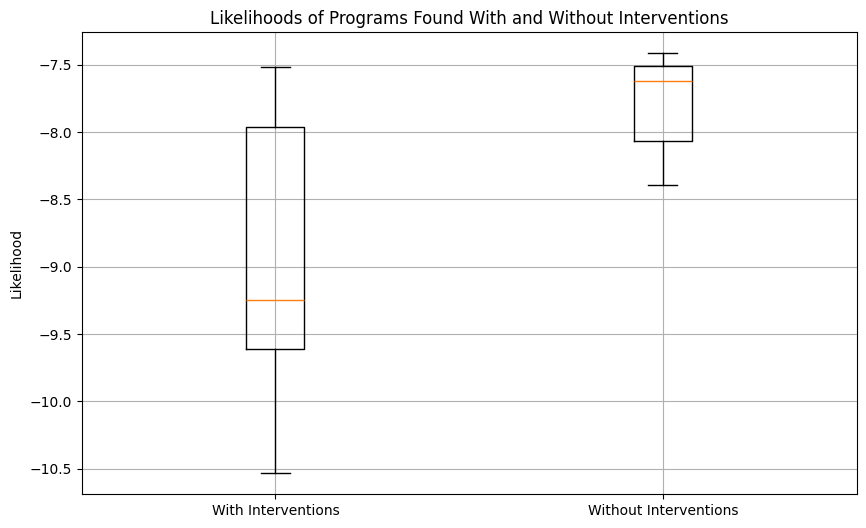

In [12]:
#create a boxplot with mean and variance of likelihoods_no_interventions and likelihoods_no_int_no_interventions
plt.figure(figsize=(10, 6))

plt.boxplot([likelihoods_no_interventions, likelihoods_no_int_no_interventions], labels=['With Interventions', 'Without Interventions'])
plt.title('Likelihoods of Programs Found With and Without Interventions')

plt.ylabel('Likelihood')
plt.grid()
plt.show()

/tmp/ipykernel_3163817/1934761811.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([likelihoods, likelihoods_no_int_filtered], labels=['With Interventions', 'Without Interventions'])


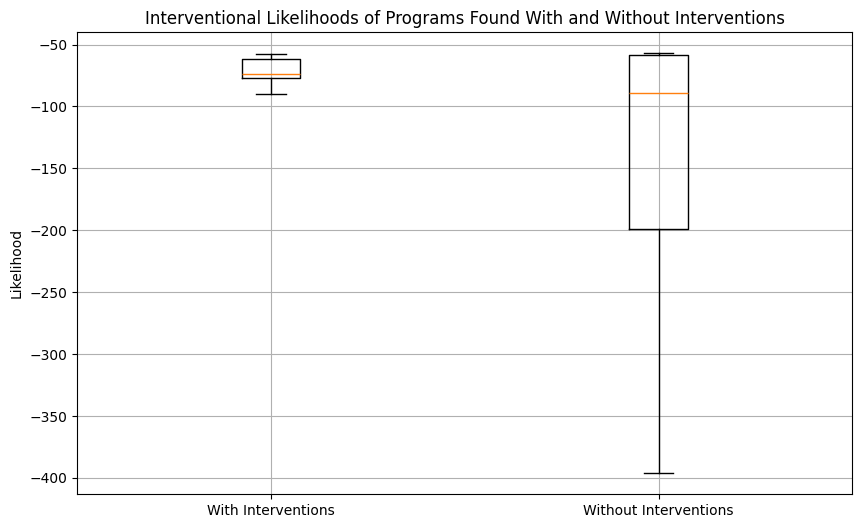

In [13]:
#create a boxplot with mean and variance of likelihoods_no_interventions and likelihoods_no_int_no_interventions
plt.figure(figsize=(10, 6))

plt.boxplot([likelihoods, likelihoods_no_int_filtered], labels=['With Interventions', 'Without Interventions'])
plt.title('Interventional Likelihoods of Programs Found With and Without Interventions')

#plt.boxplot([likelihoods_no_interventions, likelihoods_no_int_no_interventions], labels=['With Interventions', 'Without Interventions'])
#plt.title('Likelihoods of Programs Found With and Without Interventions')

plt.ylabel('Likelihood')
plt.grid()
plt.show()

In [14]:
# Create a file in the folder ../results/files with 4 columns: 
# likelihoods_no_interventions, likelihoods_no_int_no_interventions, likelihoods, likelihoods_no_int
output_file = path.join('..', 'results', 'files', ex_name + '_likelihoods.tsv')
likelihoods_df = pd.DataFrame({
    'likelihoods': likelihoods_no_interventions,
    'likelihoods_no_int': likelihoods_no_int_no_interventions,
    'interventional_likelihoods': likelihoods,
    'interventional_likelihoods_no_int': likelihoods_no_int
})
likelihoods_df = likelihoods_df.round(3)
#remove the torch.tensor from the values in the dataframe
likelihoods_df['likelihoods'] = likelihoods_df['likelihoods'].apply(lambda x: x.item() if isinstance(x, torch.Tensor) else x)
likelihoods_df['likelihoods_no_int'] = likelihoods_df['likelihoods_no_int'].apply(lambda x: x.item() if isinstance(x, torch.Tensor) else x)
likelihoods_df['interventional_likelihoods'] = likelihoods_df['interventional_likelihoods'].apply(lambda x: x.item() if isinstance(x, torch.Tensor) else x)
likelihoods_df['interventional_likelihoods_no_int'] = likelihoods_df['interventional_likelihoods_no_int'].apply(lambda x: x.item() if isinstance(x, torch.Tensor) else x)

likelihoods_df.to_csv(output_file, sep='\t', index=False)

Number of evolutionary steps aggregated: 1502


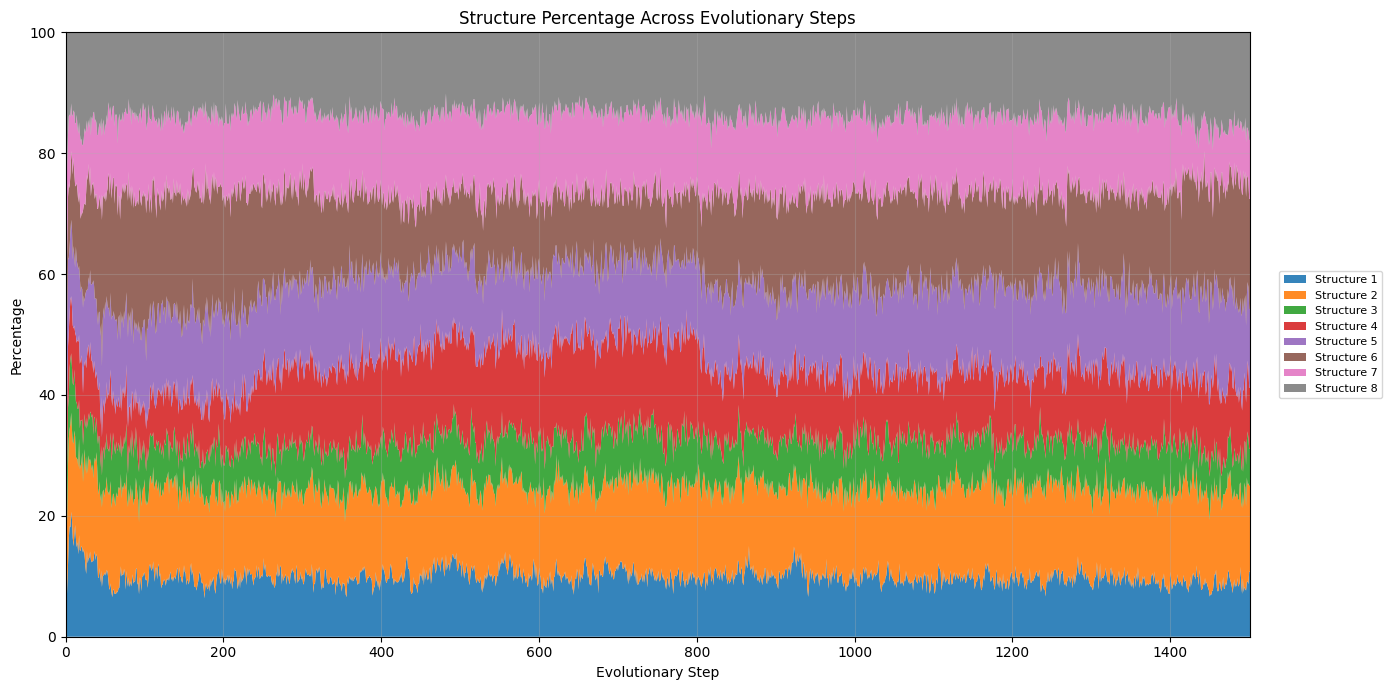

In [15]:
from collections import Counter
import re

pattern = path.join('..', 'results', ex_name, '**', 'structure.csv')
files = glob(pattern, recursive=True)

# structure_counts_aggregated[step] = Counter({structure_index: total_count_across_all_runs})
structure_counts_aggregated = []

for file in files:
    df = pd.read_csv(file, header=None)

    for step_idx, row in df.iterrows():
        while len(structure_counts_aggregated) <= step_idx:
            structure_counts_aggregated.append(Counter())

        row_text = str(row.iloc[0]).strip()
        if row_text == '' or row_text.lower() == 'nan':
            continue

        indices = [idx for idx in re.split(r'\s+', row_text) if idx != '']
        structure_counts_aggregated[step_idx].update(indices)

print(f'Number of evolutionary steps aggregated: {len(structure_counts_aggregated)}')

# Build a consistent list of all structures that appeared
all_structures = sorted({s for c in structure_counts_aggregated for s in c.keys()}, key=lambda x: int(x))
n_steps = len(structure_counts_aggregated)
x = np.arange(n_steps)

# percentages[i, t] = percentage of structure i at step t
percentages = np.zeros((len(all_structures), n_steps), dtype=float)

for t, counter in enumerate(structure_counts_aggregated):
    total = sum(counter.values())
    if total == 0:
        continue
    for i, structure in enumerate(all_structures):
        percentages[i, t] = 100.0 * counter.get(structure, 0) / total

# Stacked area chart
plt.figure(figsize=(14, 7))
plt.stackplot(x, *percentages, labels=[f'Structure {s}' for s in all_structures], alpha=0.9)
plt.title('Structure Percentage Across Evolutionary Steps')
plt.xlabel('Evolutionary Step')
plt.ylabel('Percentage')
plt.xlim(0, n_steps - 1)
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

Number of evolutionary steps aggregated: 1502


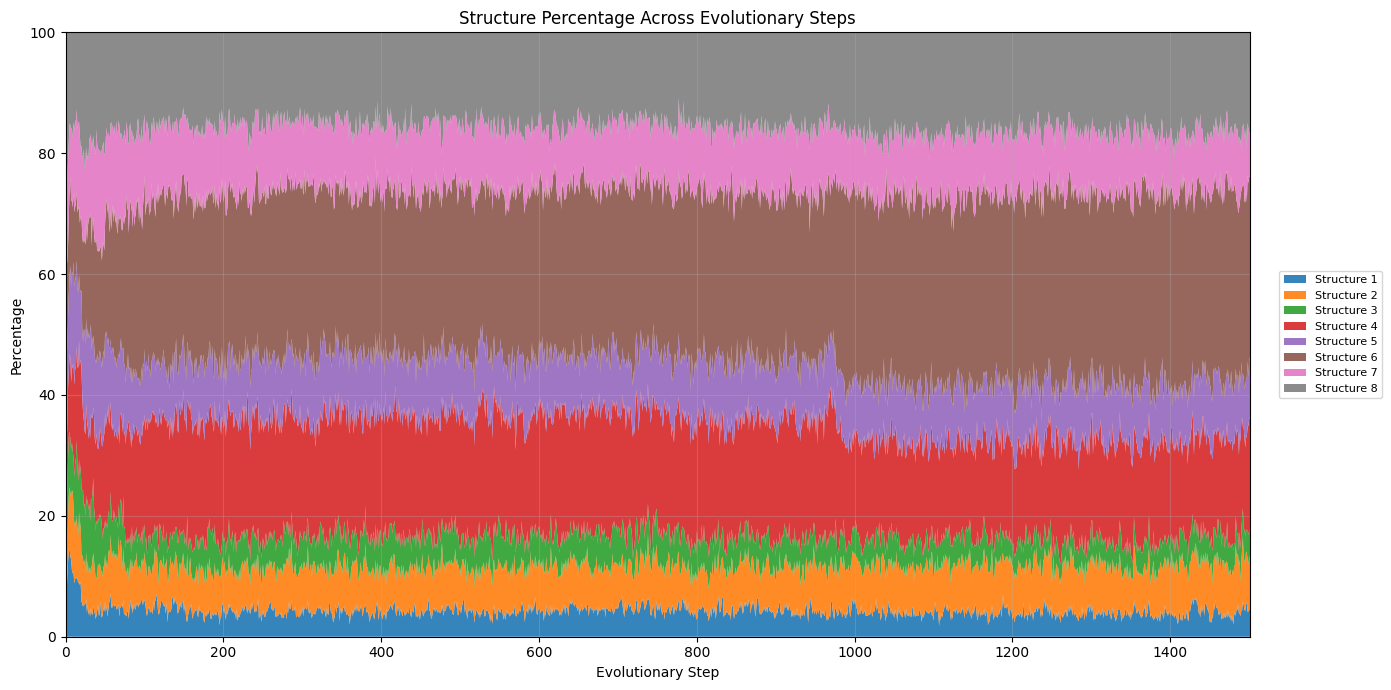

In [16]:
pattern = path.join('..', 'results', no_int_ex_name, '**', 'structure.csv')
files = glob(pattern, recursive=True)

# structure_counts_aggregated[step] = Counter({structure_index: total_count_across_all_runs})
structure_counts_aggregated = []

for file in files:
    df = pd.read_csv(file, header=None)

    for step_idx, row in df.iterrows():
        while len(structure_counts_aggregated) <= step_idx:
            structure_counts_aggregated.append(Counter())

        row_text = str(row.iloc[0]).strip()
        if row_text == '' or row_text.lower() == 'nan':
            continue

        indices = [idx for idx in re.split(r'\s+', row_text) if idx != '']
        structure_counts_aggregated[step_idx].update(indices)

print(f'Number of evolutionary steps aggregated: {len(structure_counts_aggregated)}')

# Build a consistent list of all structures that appeared
all_structures = sorted({s for c in structure_counts_aggregated for s in c.keys()}, key=lambda x: int(x))
n_steps = len(structure_counts_aggregated)
x = np.arange(n_steps)

# percentages[i, t] = percentage of structure i at step t
percentages = np.zeros((len(all_structures), n_steps), dtype=float)

for t, counter in enumerate(structure_counts_aggregated):
    total = sum(counter.values())
    if total == 0:
        continue
    for i, structure in enumerate(all_structures):
        percentages[i, t] = 100.0 * counter.get(structure, 0) / total

# Stacked area chart
plt.figure(figsize=(14, 7))
plt.stackplot(x, *percentages, labels=[f'Structure {s}' for s in all_structures], alpha=0.9)
plt.title('Structure Percentage Across Evolutionary Steps')
plt.xlabel('Evolutionary Step')
plt.ylabel('Percentage')
plt.xlim(0, n_steps - 1)
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()